# Notebook for training PyCaret Models

## a) ASVSpoof2017 Dataset

## 0. Import libraries

``librosa`` is a python package for music and audio analysis. It provides the building blocks necessary to create music information retrieval systems.

For more info vist: https://librosa.org/doc/latest/index.html

``joblib`` is a set of tools to provide lightweight pipelining in Python.

For more info visit: https://joblib.readthedocs.io/en/stable/

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from pycaret.classification import *

## 1. Data loading and preprocessing

### 1.1. Data path and labels

In [3]:
# Training audio folder
train_data_path = "../data/ASVSpoof2017/ASVspoof2017_V2_train/ASVspoof2017_V2_train"
# Development audio folder
dev_data_path = "../data/ASVSpoof2017/ASVspoof2017_V2_dev/ASVspoof2017_V2_dev"
# Evaluation audio folder
test_data_path = "../data/ASVSpoof2017/ASVspoof2017_V2_eval/ASVspoof2017_V2_eval"
# Training annotations file
train_ann_path = "../data/ASVSpoof2017/protocol_V2/ASVspoof2017_V2_train.trn.txt"
# Development annotations file
dev_ann_path = "../data/ASVSpoof2017/protocol_V2/ASVspoof2017_V2_dev.trl.txt"
# Evaluation annotations file
test_ann_path = "../data/ASVSpoof2017/protocol_V2/ASVspoof2017_V2_eval.trl.txt"

### 1.2. Functions to load data, labels, and feature extraction

In [4]:
# Load labels from the .txt file
def load_labels(note_path):
    labels = {}
    with open(note_path, 'r') as f:
        for line in f:
            parts = line.strip().split()  # Split the line by spaces
            filename = parts[0]           # Filename of the .wav file
            label = parts[1]              # Label (genuine or spoof)
            labels[filename] = 1 if label == 'genuine' else 0  # 1 for genuine, 0 for spoof
    return labels

# Apply MFCC as feature extractor
def extract_mfcc_features(file_path):
    audio, sr = librosa.load(file_path, sr=None)  # Load audio without changing original sampling rate
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)  # Extract 13 MFCC coefficients
    return np.mean(mfcc.T, axis=0)  # Average MFCC over time to get a fixed-length vector

# Function to load audios and their labels
def load_data_and_labels(data_path, labels):
    X = []
    y = []
    
    for file in os.listdir(data_path):
        file_path = os.path.join(data_path, file)
        # Extract MFCC features from the audio file
        features = extract_mfcc_features(file_path)
        X.append(features)
        y.append(labels[file])  # Corresponding label of the .wav file
    
    return np.array(X), np.array(y)

## 2. Model training

### 2.1. Prepare data for training

In [ ]:
# Load data labels
# train_labels = load_labels(train_ann_path)
# dev_labels = load_labels(dev_ann_path)
# test_labels = load_labels(test_ann_path)
train_labels = load_labels(test_ann_path)
dev_labels = load_labels(dev_ann_path)
test_labels = load_labels(train_ann_path)

# Load data features
# X_train, y_train = load_data_and_labels(train_data_path, train_labels)
# X_dev, y_dev = load_data_and_labels(dev_data_path, dev_labels)
# X_test, y_test = load_data_and_labels(test_data_path, test_labels)
X_train, y_train = load_data_and_labels(test_data_path, train_labels)
X_dev, y_dev = load_data_and_labels(dev_data_path, dev_labels)
X_test, y_test = load_data_and_labels(train_data_path, test_labels)

In [31]:
# Combine training and development data
X_combined = np.vstack((X_train, X_dev))
y_combined = np.hstack((y_train, y_dev))

In [36]:
# Calculate the proportion of the training set
train_size = len(X_train) / len(X_combined)
print(f"Train size proportion: {train_size:.2f}")

Train size proportion: 0.89


In [37]:
# Convert the MFCC features and labels into a pandas DataFrame
columns = [f'MFCC{i+1}' for i in range(X_combined.shape[1])] + ['Label']
data = pd.DataFrame(
    np.hstack((X_combined, y_combined.reshape(-1, 1))),
    columns=columns
)

### 2.2. Training and results

In [38]:
# Set up the experiment
experiment = setup(
    data=data,
    target='Label',
    train_size=train_size,
    session_id=42,
    n_jobs=2,
    fold=5,
    index=False,
    log_experiment=False,
    log_plots=False,
    log_profile=False,
    profile=False,
)

,Description,Value
0,Session id,42
1,Target,Label
2,Target type,Binary
3,Original data shape,"(15016, 14)"
4,Transformed data shape,"(15016, 14)"
5,Transformed train set shape,"(13306, 14)"
6,Transformed test set shape,"(1710, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [40]:
# Models available in PyCaret for classification
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [42]:
# Compare models to select the best one
best_model = compare_models(turbo=True, sort='f1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9569,0.9844,0.7829,0.8892,0.8326,0.8080,0.8102,0.1380
lightgbm,Light Gradient Boosting Machine,0.9521,0.9807,0.7484,0.8847,0.8107,0.7836,0.7872,0.1080
knn,K Neighbors Classifier,0.9460,0.9671,0.7851,0.8147,0.7994,0.7683,0.7686,0.1280
et,Extra Trees Classifier,0.9479,0.9895,0.6502,0.9562,0.7737,0.7455,0.7634,0.2460
rf,Random Forest Classifier,0.9387,0.9813,0.5943,0.9353,0.7265,0.6939,0.7167,0.7800
qda,Quadratic Discriminant Analysis,0.8913,0.9348,0.7303,0.5830,0.6483,0.5850,0.5902,0.0220
dt,Decision Tree Classifier,0.9003,0.7922,0.6431,0.6350,0.6390,0.5812,0.5812,0.0820
gbc,Gradient Boosting Classifier,0.9163,0.9491,0.4879,0.8320,0.6150,0.5716,0.5974,2.6740
ada,Ada Boost Classifier,0.8937,0.9083,0.4737,0.6558,0.5500,0.4915,0.4999,0.5660
nb,Naive Bayes,0.8341,0.8663,0.7122,0.4360,0.5407,0.4466,0.4667,0.0180


In [44]:
# Adjust hyperparameters for the best model
tuned_model = tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9414,0.9835,0.9041,0.7317,0.8088,0.7747,0.7807
1,0.9455,0.9845,0.9231,0.7417,0.8225,0.7908,0.7974
2,0.9553,0.9889,0.9397,0.7795,0.8522,0.8261,0.8311
3,0.9519,0.9833,0.9096,0.7775,0.8384,0.8103,0.8138
4,0.9436,0.9830,0.8932,0.7460,0.8130,0.7801,0.7845
Mean,0.9475,0.9847,0.9139,0.7553,0.8270,0.7964,0.8015
Std,0.0052,0.0022,0.0161,0.0195,0.0162,0.0192,0.0188


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [45]:
# Train the tuned model with all the data (train and dev)
final_model = finalize_model(tuned_model)

In [46]:
# Evaluation of the model with the test data
test_data = pd.DataFrame(
    np.hstack((X_test, y_test.reshape(-1, 1))),
    columns=columns
)
predictions = predict_model(final_model, data=test_data)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.7946,0.9484,0.6184,0.9549,0.7507,0.5893,0.6296


### 2.3. Best Model Plots

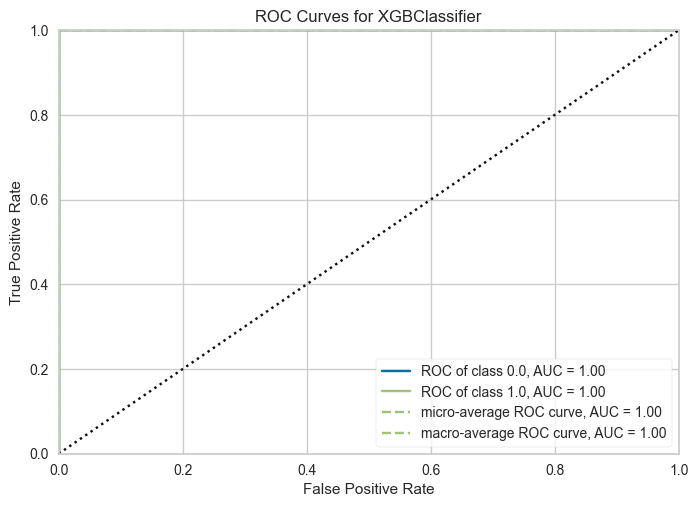

In [47]:
# ROC Curves plot
plot_model(final_model, plot='auc')

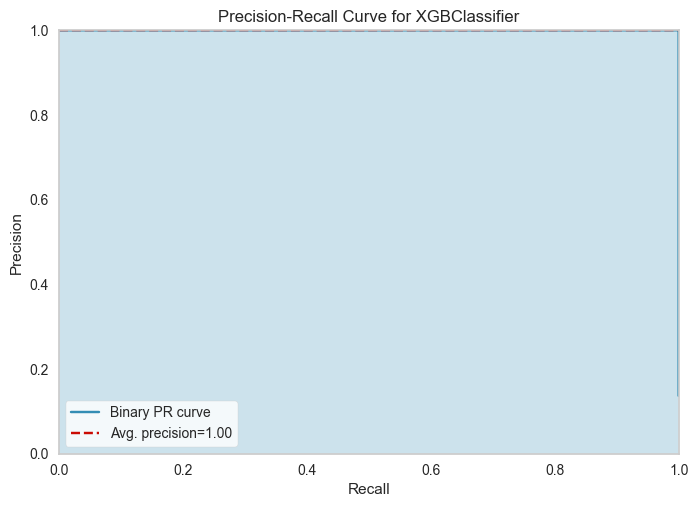

In [48]:
# Precision-Recall Curve plot
plot_model(final_model, plot='pr')

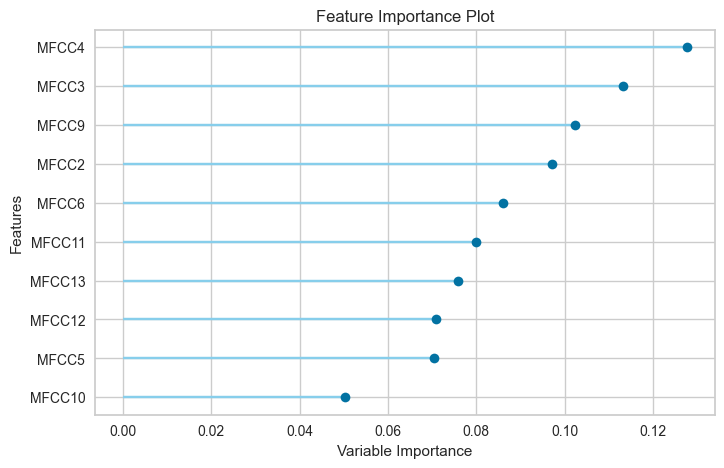

In [49]:
# Feature Importance plot
plot_model(final_model, plot='feature')

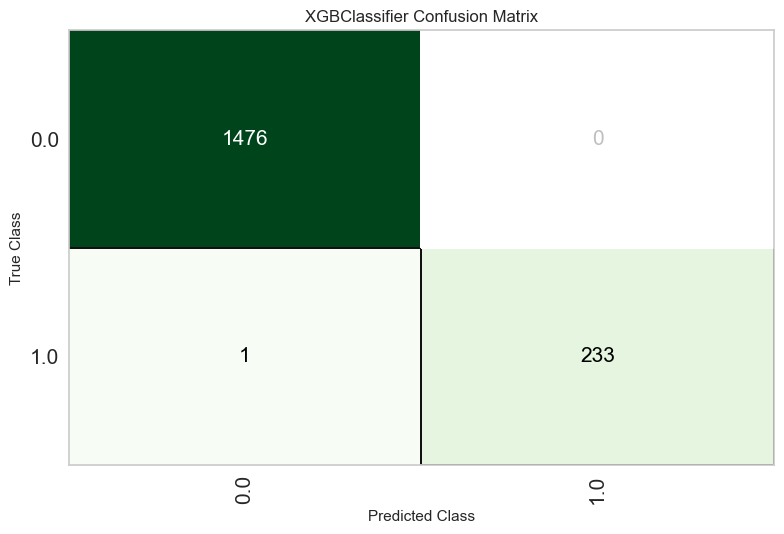

In [50]:
# Confusion Matrix plot
plot_model(final_model, plot='confusion_matrix')

In [51]:
# Generic model evaluation
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [52]:
# Train and dev data predictions
predict_model(final_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9994,1.0000,0.9957,1.0000,0.9979,0.9975,0.9975


,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,Label,prediction_label,prediction_score
13306,-228.727051,135.415878,42.463985,35.115715,-4.000930,21.746614,5.507431,-12.386960,-12.919845,1.293648,-1.060361,1.047704,-4.458732,0.0,0,0.9993
13307,-212.425201,7.503144,-18.810143,-32.669556,-21.228922,-16.768232,-22.683311,-17.032587,-13.148618,2.718672,-4.895867,-1.995739,-9.383647,0.0,0,0.9999
13308,-280.154633,124.236862,58.201794,22.637356,-5.817938,1.850712,-9.462764,-15.157485,-6.361027,-6.239093,-7.502828,-14.819016,-17.042683,0.0,0,0.9995
13309,-149.680237,21.606482,-30.581755,1.593120,-27.250839,-23.903692,-20.635809,-1.563937,-11.295964,-12.031227,-1.497394,-5.479378,-6.531618,0.0,0,1.0000
13310,-284.076599,48.707413,18.645958,23.558962,-20.348988,20.427225,-33.056839,5.790687,-30.209391,7.062316,-31.182671,4.750633,-17.502680,0.0,0,0.9575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15011,-236.379929,93.593140,-1.154662,26.090021,-8.030827,9.176010,-1.465746,2.106796,-12.420464,4.548588,-6.473795,-0.133482,-7.349622,1.0,1,0.8104
15012,-195.237335,151.677948,-13.219353,43.387775,-10.351933,-15.655935,-14.614464,2.649905,-13.095153,1.451017,-10.808152,-8.153879,-6.689951,0.0,0,0.9998
15013,-113.171227,81.005257,-34.021019,-33.137993,-17.659180,-35.418949,-5.210083,-16.484350,-9.369248,-8.906608,-14.635073,-11.307765,-4.432404,0.0,0,1.0000
15014,-134.226517,104.611877,-9.658877,7.465582,-5.284072,2.602483,-26.650856,4.092172,-27.615465,8.148772,-4.204597,6.530359,-3.961353,0.0,0,0.9996


## b) ASVSpoof2019 Dataset

## 1. Data loading and preprocessing

### 1.1. Data path and labels

In [53]:
# Training audio folder
train_data_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_train/flac"
# Development audio folder
dev_data_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_dev/flac"
# Evaluation audio folder
test_data_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_eval/flac"
# Training annotations file
train_ann_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt"
# Development annotations file
dev_ann_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.dev.trl.txt"
# Evaluation annotations file
test_ann_path = "../data/ASVSpoof2019/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.eval.trl.txt"

### 1.2. Functions to load data, labels, and feature extraction

In [68]:
# Load labels from the .txt file
def load_labels(note_path):
    labels = {}
    with open(note_path, 'r') as f:
        for line in f:
            parts = line.strip().split()  # Split the line by spaces
            filename = f"{parts[1]}.flac"           # Filename of the .flac file
            label = parts[-1]              # Label (genuine or spoof)
            labels[filename] = 1 if label == 'bonafide' else 0  # 1 for bonafide, 0 for spoof
    return labels

# Apply MFCC as feature extractor
def extract_mfcc_features(file_path):
    audio, sr = librosa.load(file_path, sr=None)  # Load audio without changing original sampling rate
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)  # Extract 13 MFCC coefficients
    return np.mean(mfcc.T, axis=0)  # Average MFCC over time to get a fixed-length vector

# Function to load audios and their labels
def load_data_and_labels(data_path, labels):
    X = []
    y = []
    
    for file in os.listdir(data_path):
        if file[5] != 'A':
            file_path = os.path.join(data_path, file)
            # Extract MFCC features from the audio file
            features = extract_mfcc_features(file_path)
            X.append(features)
            y.append(labels[file])  # Corresponding label of the .flac file
        
    return np.array(X), np.array(y)

## 2. Model training

### 2.1. Prepare data for training

In [77]:
# Load data labels
# train_labels = load_labels(train_ann_path)
# dev_labels = load_labels(dev_ann_path)
# test_labels = load_labels(test_ann_path)
train_labels = load_labels(test_ann_path)
dev_labels = load_labels(dev_ann_path)
test_labels = load_labels(train_ann_path)

# Load data features
# X_train, y_train = load_data_and_labels(train_data_path, train_labels)
# X_dev, y_dev = load_data_and_labels(dev_data_path, dev_labels)
# X_test, y_test = load_data_and_labels(test_data_path, test_labels)
X_train, y_train = load_data_and_labels(test_data_path, train_labels)
X_dev, y_dev = load_data_and_labels(dev_data_path, dev_labels)
X_test, y_test = load_data_and_labels(train_data_path, test_labels)

In [89]:
# Combine training and development data
X_combined = np.vstack((X_train, X_dev))
y_combined = np.hstack((y_train, y_dev))

In [90]:
# Calculate the proportion of the training set
train_size = len(X_train) / len(X_combined)
print(f"Train size proportion: {train_size:.2f}")

Train size proportion: 0.82


In [91]:
# Convert the MFCC features and labels into a pandas DataFrame
columns = [f'MFCC{i+1}' for i in range(X_combined.shape[1])] + ['Label']
data = pd.DataFrame(
    np.hstack((X_combined, y_combined.reshape(-1, 1))),
    columns=columns
)

### 2.2. Training and results

In [93]:
# Set up the experiment
experiment = setup(
    data=data,
    target='Label',
    train_size=train_size,
    session_id=42,
    n_jobs=2,
    fold=5,
    index=False,
    log_experiment=False,
    log_plots=False,
    log_profile=False,
    profile=False,
)

,Description,Value
0,Session id,42
1,Target,Label
2,Target type,Binary
3,Original data shape,"(164430, 14)"
4,Transformed data shape,"(164430, 14)"
5,Transformed train set shape,"(134730, 14)"
6,Transformed test set shape,"(29700, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [94]:
# Models available in PyCaret for classification
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [95]:
# Compare models to select the best one
best_model = compare_models(turbo=True, sort='f1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.8801,0.8742,0.4986,0.5959,0.5429,0.4745,0.4770,6.4660
qda,Quadratic Discriminant Analysis,0.8330,0.8381,0.4425,0.4200,0.4308,0.3331,0.3333,0.1220
dt,Decision Tree Classifier,0.8279,0.6579,0.4199,0.4020,0.4107,0.3100,0.3101,1.3460
nb,Naive Bayes,0.7672,0.7828,0.5315,0.3140,0.3948,0.2623,0.2762,0.1160
xgboost,Extreme Gradient Boosting,0.8736,0.8853,0.2673,0.6375,0.3766,0.3191,0.3567,0.6840
rf,Random Forest Classifier,0.8798,0.8978,0.2370,0.7512,0.3603,0.3132,0.3777,14.0560
et,Extra Trees Classifier,0.8797,0.9035,0.2294,0.7626,0.3527,0.3069,0.3753,3.8660
lightgbm,Light Gradient Boosting Machine,0.8687,0.8759,0.1925,0.6325,0.2951,0.2448,0.2983,0.6680
ada,Ada Boost Classifier,0.8560,0.8241,0.1445,0.4873,0.2227,0.1684,0.2069,6.4440
gbc,Gradient Boosting Classifier,0.8621,0.8479,0.1028,0.6029,0.1756,0.1397,0.2076,35.2880


In [96]:
# Adjust hyperparameters for the best model
tuned_model = tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8872,0.8939,0.3791,0.6921,0.4898,0.4325,0.4573
1,0.8904,0.8995,0.3869,0.7148,0.5020,0.4465,0.4732
2,0.8892,0.8988,0.3892,0.7026,0.5009,0.4443,0.4689
3,0.8879,0.8928,0.3818,0.6967,0.4933,0.4363,0.4613
4,0.8894,0.8959,0.3906,0.7031,0.5023,0.4457,0.4701
Mean,0.8888,0.8962,0.3855,0.7019,0.4977,0.4410,0.4662
Std,0.0011,0.0026,0.0044,0.0076,0.0051,0.0056,0.0059


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [97]:
# Train the tuned model with all the data (train and dev)
final_model = finalize_model(tuned_model)

### 2.3. Best Model Plots

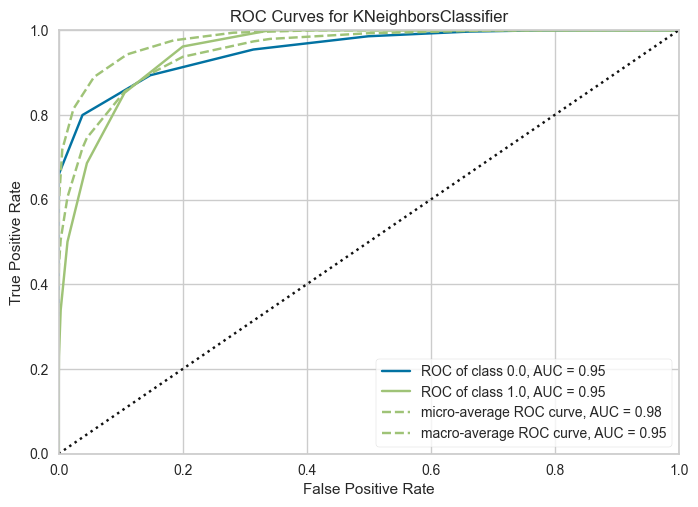

In [98]:
# ROC Curves plot
plot_model(final_model, plot='auc')

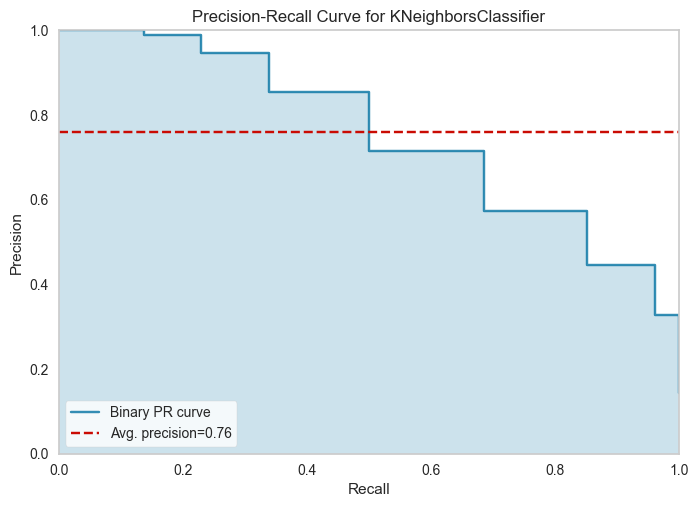

In [99]:
# Precision-Recall Curve plot
plot_model(final_model, plot='pr')

In [102]:
best_model

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=2, n_neighbors=5, p=2,
                     weights='uniform')

In [106]:
# Feature Importance plot
# plot_model(final_model, plot='feature')

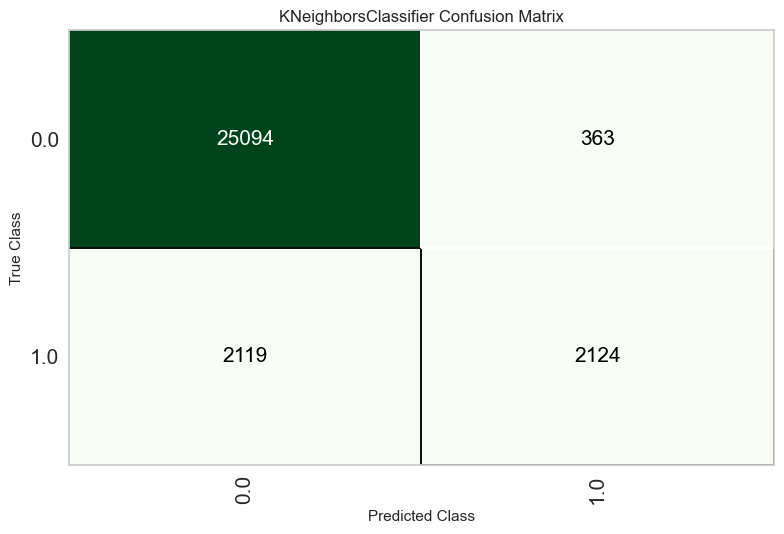

In [103]:
# Confusion Matrix plot
plot_model(final_model, plot='confusion_matrix')

In [104]:
# Generic model evaluation
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [105]:
# Train and dev data predictions
predict_model(final_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9164,0.9530,0.5006,0.8540,0.6312,0.5877,0.6144


,MFCC1,MFCC2,MFCC3,MFCC4,MFCC5,MFCC6,MFCC7,MFCC8,MFCC9,MFCC10,MFCC11,MFCC12,MFCC13,Label,prediction_label,prediction_score
134730,-344.133636,44.961876,-2.802089,14.648546,-8.282830,-2.780077,-16.067690,-18.494511,-13.595705,-9.065837,-10.729153,-7.010945,-5.118242,0.0,0,1.000
134731,-378.083435,3.432686,-14.250755,11.156610,-38.509750,2.481572,-24.730608,-28.584513,20.028242,3.125791,20.661303,-1.139884,-28.924929,0.0,0,1.000
134732,-304.198120,41.161812,9.719212,7.528100,-3.098947,-21.308273,-13.704472,-11.460223,-9.134366,-2.861481,-0.998435,3.076072,-8.520303,0.0,0,1.000
134733,-320.961395,64.054077,-3.038996,14.392093,-5.431719,-13.550575,-33.566391,-32.311253,-23.492477,-23.518782,-8.875115,-2.041142,-7.776943,0.0,0,1.000
134734,-342.936127,52.264938,24.826090,35.147007,5.489395,2.888126,-6.704834,-3.352940,6.452991,-4.080353,-14.792497,-7.138518,-13.078297,0.0,0,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164425,-328.219574,70.928833,11.686350,18.724854,-3.143722,-2.762581,4.035735,-3.292733,-11.113652,2.620358,4.147029,0.938992,-0.371268,0.0,0,1.000
164426,-366.985016,70.250809,20.258728,31.255571,7.017605,-0.674820,-9.375562,-15.738283,-19.349979,-8.261288,-8.928306,-6.499426,-6.957902,0.0,0,0.875
164427,-362.004028,93.270309,15.548038,13.894504,1.751428,0.203044,0.893567,-10.014726,-8.474711,-14.098912,-13.468932,-6.685411,-9.315631,0.0,0,1.000
164428,-241.844376,40.005390,-5.391953,0.546649,-11.486262,-5.573524,-32.072582,-9.273210,-14.659323,-31.929062,-10.458905,-9.457675,-9.980584,0.0,0,1.000
